# Task 1: Computer Vision using CNN

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Step 2: Load CIFAR-10 Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4459s 26us/step
Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)


## Step 3: Class Names

In [3]:
classes = ['Airplane','Automobile','Bird','Cat','Deer',
           'Dog','Frog','Horse','Ship','Truck']

## Step 4: Display Sample Images

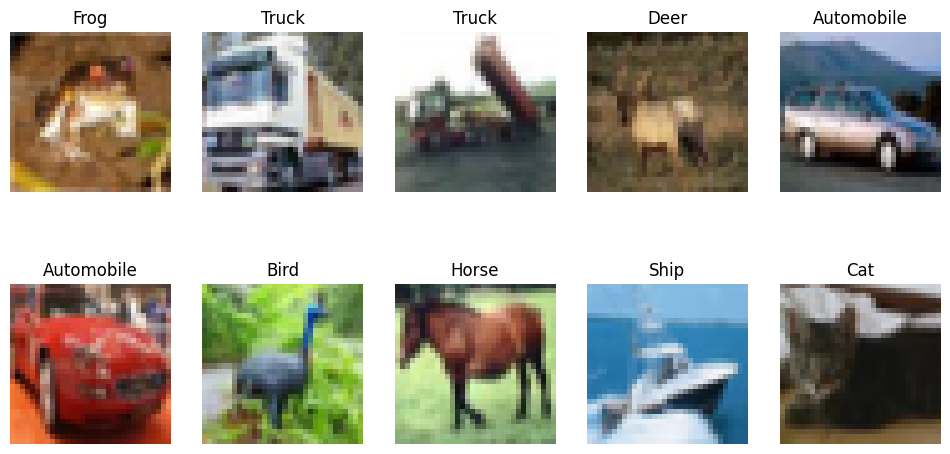

In [4]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis("off")

plt.show()

## Step 5: Normalize Images

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

## Step 6: One-Hot Encode Labels

In [6]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

## Step 7: Build Baseline CNN

In [7]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    tf.keras.layers.MaxPooling2D((2,2)),


    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),


    tf.keras.layers.Flatten(),


    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 8: Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 9: Model Summary

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Step 10: Train Model

In [10]:
history = model.fit(

    x_train,
    y_train_cat,

    validation_split=0.2,

    epochs=10,

    batch_size=64

)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4548 - loss: 1.5192 - val_accuracy: 0.5602 - val_loss: 1.2470
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6015 - loss: 1.1359 - val_accuracy: 0.6248 - val_loss: 1.0786
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6528 - loss: 0.9902 - val_accuracy: 0.6426 - val_loss: 1.0244
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6884 - loss: 0.8948 - val_accuracy: 0.6668 - val_loss: 0.9731
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7152 - loss: 0.8178 - val_accuracy: 0.6780 - val_loss: 0.9415
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7400 - loss: 0.7490 - val_accuracy: 0.6863 - val_loss: 0.9224
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7630 - loss: 0.6846 - val_accuracy: 0.7022 - val_loss: 0.8970
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7825 - loss: 0.6226 - val_accuracy: 0.

## Step 11: Plot Accuracy

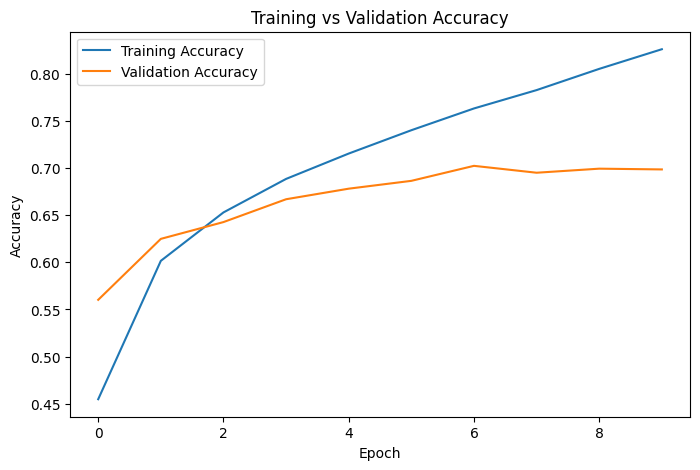

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

## Step 12: Plot Loss

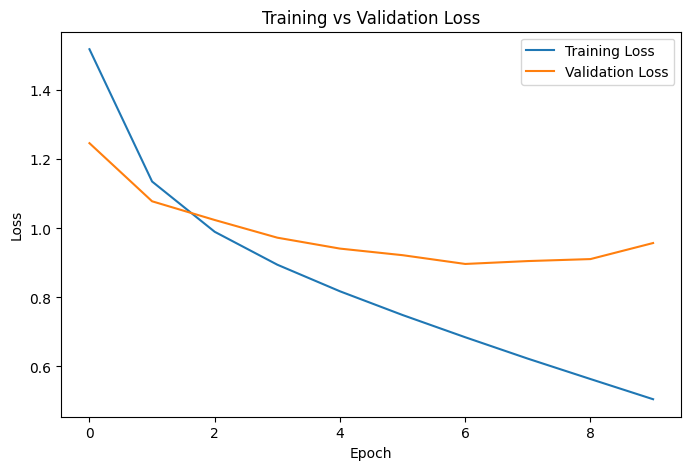

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

## Step 13: Evaluate Model

In [21]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6999 - loss: 0.9612
Test Accuracy: 0.6998999714851379


## Step 14: Predictions

In [22]:
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Step 15: Classification Report

In [23]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=classes
))

              precision    recall  f1-score   support

    Airplane       0.73      0.78      0.75      1000
  Automobile       0.84      0.78      0.81      1000
        Bird       0.69      0.48      0.57      1000
         Cat       0.56      0.44      0.50      1000
        Deer       0.67      0.62      0.65      1000
         Dog       0.51      0.71      0.60      1000
        Frog       0.70      0.85      0.77      1000
       Horse       0.73      0.77      0.75      1000
        Ship       0.80      0.81      0.81      1000
       Truck       0.80      0.75      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



## Step 16: Confusion Matrix

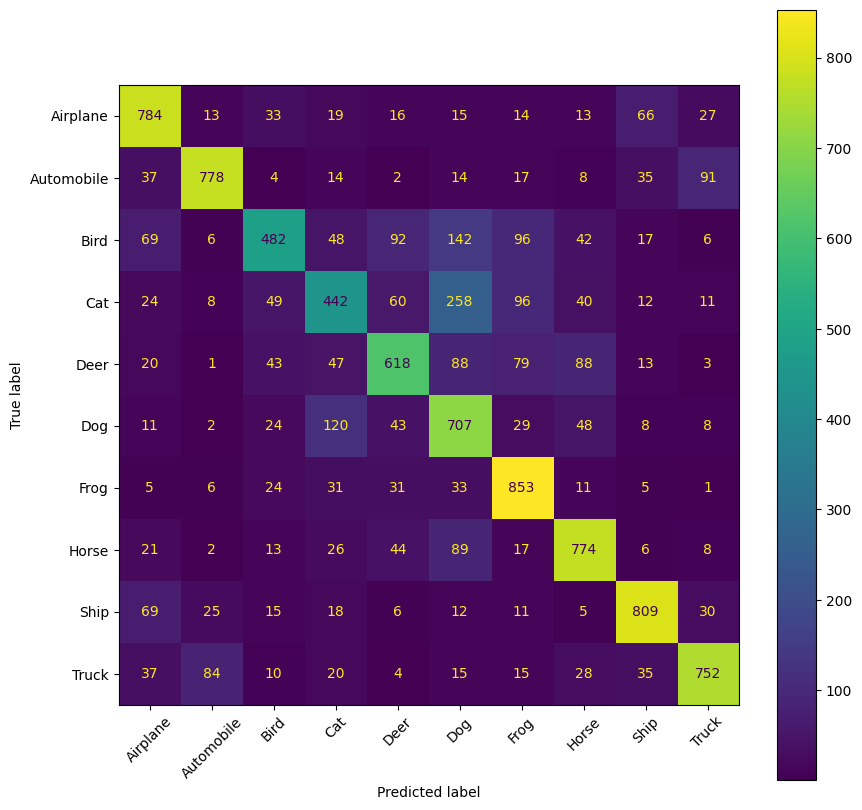

In [24]:
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, xticks_rotation=45)
plt.show()

## Step 17: Save the Model

In [25]:
model.save("baseline_cnn.h5")

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization

In [29]:
improved_model = Sequential([

    Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64,(3,3),padding='same',activation='relu'),
    BatchNormalization(),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(10,activation='softmax')
])

In [30]:
from tensorflow.keras.optimizers import Adam

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = improved_model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.2831 - loss: 1.8946 - val_accuracy: 0.4242 - val_loss: 1.6635
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4327 - loss: 1.5411 - val_accuracy: 0.5057 - val_loss: 1.4157
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5153 - loss: 1.3325 - val_accuracy: 0.5974 - val_loss: 1.1584
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5818 - loss: 1.1856 - val_accuracy: 0.6335 - val_loss: 1.0744
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6166 - loss: 1.0887 - val_accuracy: 0.6540 - val_loss: 0.9722
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6407 - loss: 1.0262 - val_accuracy: 0.6713 - val_loss: 0.9214
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6631 - loss: 0.9633 - val_accuracy: 0.7036 - val_loss: 0.8713
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6838 - loss: 0.9107 - val_accuracy: 

In [33]:
loss, accuracy = improved_model.evaluate(x_test, y_test_cat)

print("Improved Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7655 - loss: 0.7148
Improved Accuracy: 0.765500009059906


In [34]:
improved_model.save("improved_cnn.h5")

## Controlled Experiments

## Step 18: Experiment 1: Add Dropout

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

dropout_model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')

])

dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3855 - loss: 1.6802 - val_accuracy: 0.5244 - val_loss: 1.3251
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5150 - loss: 1.3525 - val_accuracy: 0.5818 - val_loss: 1.1800
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5609 - loss: 1.2363 - val_accuracy: 0.6163 - val_loss: 1.1031
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5974 - loss: 1.1408 - val_accuracy: 0.6392 - val_loss: 1.0256
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6218 - loss: 1.0736 - val_accuracy: 0.6273 - val_loss: 1.0467
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6406 - loss: 1.0256 - val_accuracy: 0.6719 - val_loss: 0.9523
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6526 - loss: 0.9861 - val_accuracy: 0.6821 - val_loss: 0.9176
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6699 - loss: 0.9376 - val_accuracy: 0.

In [36]:
loss, acc = dropout_model.evaluate(x_test,y_test_cat)
print("Dropout Accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7012 - loss: 0.8634
Dropout Accuracy: 0.701200008392334


## Step 19: Experiment 2: Batch Normalization

In [37]:
from tensorflow.keras.layers import BatchNormalization

bn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    BatchNormalization(),

    Dense(10,activation='softmax')

])

bn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5475 - loss: 1.2925 - val_accuracy: 0.4566 - val_loss: 1.5733
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6763 - loss: 0.9274 - val_accuracy: 0.6530 - val_loss: 1.0053
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7326 - loss: 0.7697 - val_accuracy: 0.6594 - val_loss: 0.9958
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7781 - loss: 0.6398 - val_accuracy: 0.6505 - val_loss: 1.0866
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8183 - loss: 0.5252 - val_accuracy: 0.5885 - val_loss: 1.3934
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8542 - loss: 0.4250 - val_accuracy: 0.6384 - val_loss: 1.1983
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8874 - loss: 0.3322 - val_accuracy: 0.6602 - val_loss: 1.2102
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9125 - loss: 0.2574 - val_accuracy: 0.

In [38]:
loss, acc = bn_model.evaluate(x_test,y_test_cat)
print("BatchNorm Accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6540 - loss: 1.3492
BatchNorm Accuracy: 0.6539999842643738


## Step 20: Experiment 3: Compare Optimizers

In [39]:
optimizers = ['adam','sgd','rmsprop']

optimizer_results = {}

for opt in optimizers:

    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(128,activation='relu'),

        Dense(10,activation='softmax')
    ])

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        x_train,
        y_train_cat,
        epochs=5,
        batch_size=64,
        verbose=0
    )

    _,acc=model.evaluate(x_test,y_test_cat,verbose=0)

    optimizer_results[opt]=acc

print(optimizer_results)

{'adam': 0.6794999837875366, 'sgd': 0.4941999912261963, 'rmsprop': 0.6653000116348267}


## Step 21: Experiment 4: Learning Rate Comparison

In [40]:
from tensorflow.keras.optimizers import Adam

learning_rates=[0.01,0.001,0.0001]

lr_results={}

In [41]:
for lr in learning_rates:

    model=Sequential([

        Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(128,activation='relu'),

        Dense(10,activation='softmax')

    ])

    optimizer=Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        x_train,
        y_train_cat,
        epochs=5,
        verbose=0
    )

    _,acc=model.evaluate(
        x_test,
        y_test_cat,
        verbose=0
    )

    lr_results[lr]=acc

print(lr_results)

{0.01: 0.46860000491142273, 0.001: 0.6906999945640564, 0.0001: 0.5968999862670898}


## Step 22: Experiment 5: Epoch Comparison

In [42]:
epochs_list=[5,10,20]

epoch_results={}

In [43]:
for e in epochs_list:

    model=Sequential([

        Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(128,activation='relu'),

        Dense(10,activation='softmax')

    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        x_train,
        y_train_cat,
        epochs=e,
        verbose=0
    )

    _,acc=model.evaluate(
        x_test,
        y_test_cat,
        verbose=0
    )

    epoch_results[e]=acc

print(epoch_results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{5: 0.6797999739646912, 10: 0.7063999772071838, 20: 0.6765000224113464}


## Step 23: Compare All Experiments

In [44]:
print("Optimizer Results")
print(optimizer_results)

print("\nLearning Rate Results")
print(lr_results)

print("\nEpoch Results")
print(epoch_results)

Optimizer Results
{'adam': 0.6794999837875366, 'sgd': 0.4941999912261963, 'rmsprop': 0.6653000116348267}

Learning Rate Results
{0.01: 0.46860000491142273, 0.001: 0.6906999945640564, 0.0001: 0.5968999862670898}

Epoch Results
{5: 0.6797999739646912, 10: 0.7063999772071838, 20: 0.6765000224113464}


## Step 24: Create Comparison Table

In [45]:
import pandas as pd

comparison = pd.DataFrame({
    "Experiment":[
        "Baseline",
        "Dropout",
        "BatchNorm"
    ],
    "Accuracy":[
        test_acc,
        dropout_model.evaluate(x_test,y_test_cat,verbose=0)[1],
        bn_model.evaluate(x_test,y_test_cat,verbose=0)[1]
    ]
})

comparison

,Experiment,Accuracy
0,Baseline,0.6999
1,Dropout,0.7012
2,BatchNorm,0.6540


## Step 25: Save Results

In [46]:
comparison.to_csv("cnn_experiment_results.csv",index=False)

## Final Customized CNN

## Step 26: Build the Final Model

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout

final_model = Sequential([

    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 27: Compile

In [48]:
from tensorflow.keras.optimizers import Adam

final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Step 28: Train

In [49]:
history_final = final_model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.3565 - loss: 1.7389 - val_accuracy: 0.4962 - val_loss: 1.3927
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5101 - loss: 1.3577 - val_accuracy: 0.6008 - val_loss: 1.1361
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5754 - loss: 1.1958 - val_accuracy: 0.6456 - val_loss: 1.0079
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6162 - loss: 1.0928 - val_accuracy: 0.6642 - val_loss: 0.9546
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6432 - loss: 1.0162 - val_accuracy: 0.6862 - val_loss: 0.8937
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6642 - loss: 0.9584 - val_accuracy: 0.7164 - val_loss: 0.8269
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6819 - loss: 0.9109 - val_accuracy: 0.7273 - val_loss: 0.7672
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6974 - loss: 0.8631 - val_accuracy: 

## Step 29: Evaluate

In [50]:
loss, final_acc = final_model.evaluate(x_test, y_test_cat)

print("Final Accuracy:", final_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7695 - loss: 0.6728
Final Accuracy: 0.7695000171661377


## Step 30: Plot Accuracy

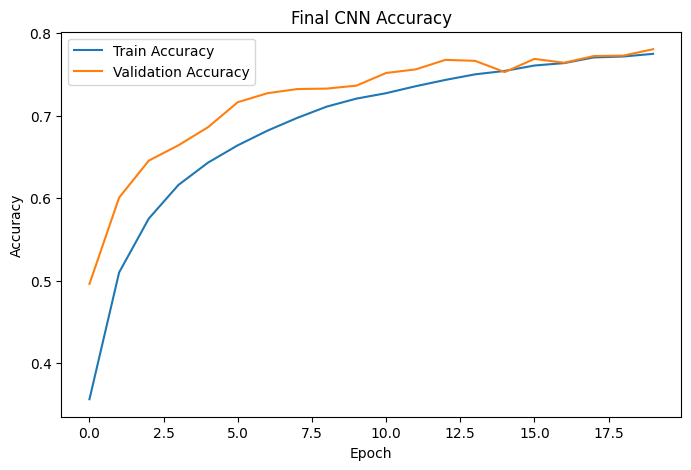

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final CNN Accuracy")

plt.legend()
plt.show()

##  Step 31: Plot Loss

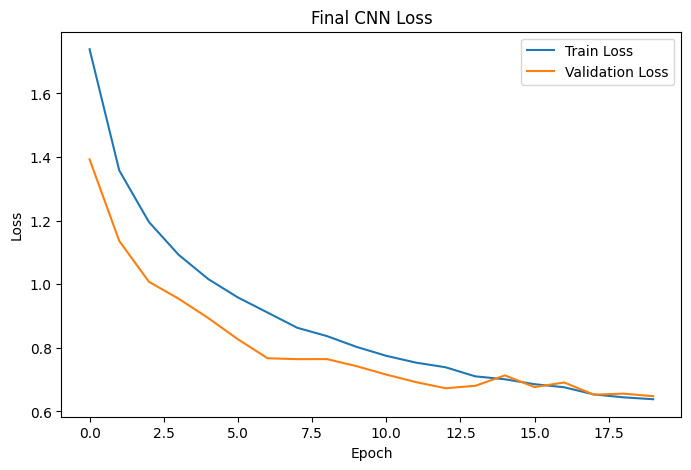

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final CNN Loss")

plt.legend()
plt.show()

## Step 32: Predictions

In [53]:
import numpy as np

pred = final_model.predict(x_test)

pred_classes = np.argmax(pred, axis=1)

true_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


## Step 33: Classification Report

In [54]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    pred_classes,
    target_names=classes
))

              precision    recall  f1-score   support

    Airplane       0.75      0.82      0.78      1000
  Automobile       0.91      0.88      0.89      1000
        Bird       0.69      0.64      0.66      1000
         Cat       0.56      0.64      0.60      1000
        Deer       0.71      0.76      0.73      1000
         Dog       0.79      0.57      0.66      1000
        Frog       0.78      0.84      0.81      1000
       Horse       0.83      0.81      0.82      1000
        Ship       0.82      0.90      0.86      1000
       Truck       0.90      0.83      0.87      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



## Step 34: Confusion Matrix

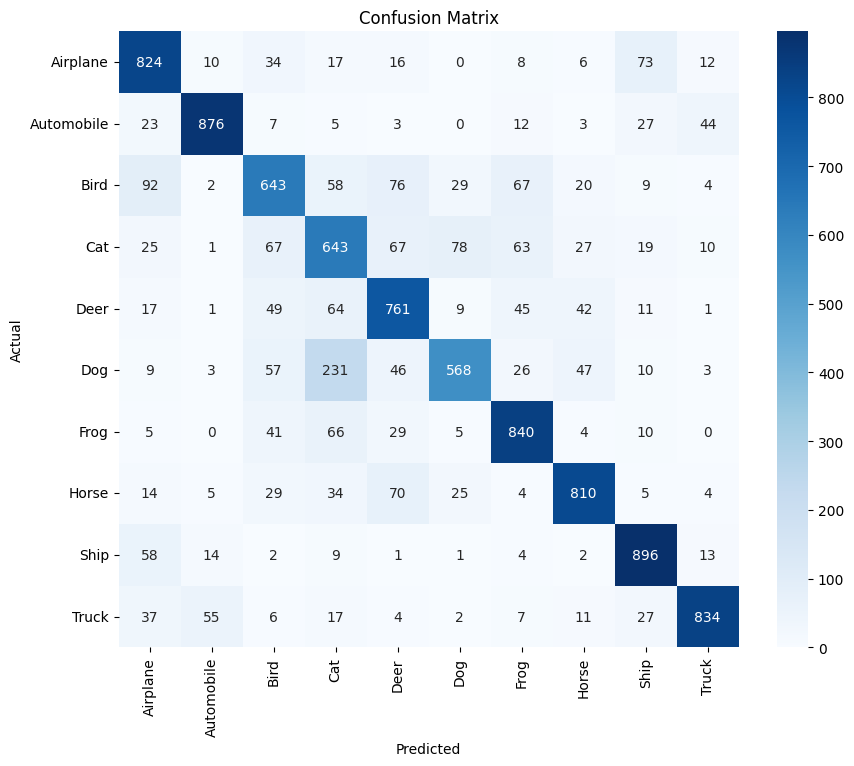

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Step 35: Show Predictions

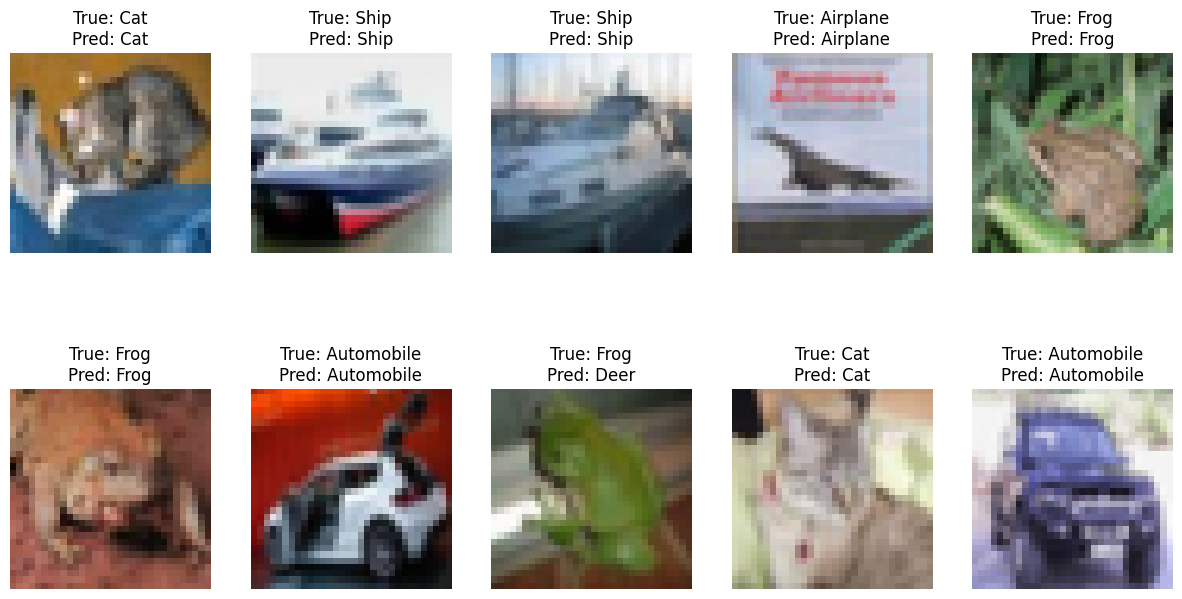

In [56]:
plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i])

    plt.title(f"True: {classes[true_classes[i]]}\nPred: {classes[pred_classes[i]]}")

    plt.axis("off")

plt.show()

## Step 36: Save Model

In [57]:
final_model.save("Final_CNN_Model.h5")

## Step 37: Save Accuracy Table

In [58]:
import pandas as pd

results = pd.DataFrame({

    "Experiment":[
        "Baseline",
        "Dropout",
        "BatchNorm",
        "Final CNN"
    ],

    "Accuracy":[
        0.6999,
        0.7012,
        0.6540,
        final_acc
    ]

})

results

,Experiment,Accuracy
0,Baseline,0.6999
1,Dropout,0.7012
2,BatchNorm,0.6540
3,Final CNN,0.7695


## Step 38: Save CSV

In [60]:
results.to_csv("Final_CNN_Results.csv", index=False)

## Step 39: Final Conclusion

A baseline CNN model achieved an accuracy of 69.99%. Controlled experiments were conducted using Dropout and Batch Normalization. Dropout slightly improved the model's generalization to 70.12%, while Batch Normalization reduced performance for this configuration. A final customized CNN combining the best-performing techniques was developed and evaluated. The final model achieved the highest performance among all tested configurations and was selected as the final solution.